# OxfordIIITPet dataset Classification


# Projet de session 2 pour le cours M2MAS "Réseaux de Neurones profonds pour l'Apprentissage", année 2024-2025

## Bruno Galerne

Fichier NOM_Prenom_M2MAS_session2_202425_OxfordIIITPet.ipynb à envoyer par email à bruno.galerne@univ-orleans.fr pour le **vendredi 5 septembre 2025 avant 20h**.

Le code ci-dessous permet d'entraîner un réseau de neurones convolutionnel pour effectuer la classification de la base d'une base de d'images.

In [5]:
import torch # modèle
import torch.nn as nn # couche
import torch.optim as optim # optimiseur
from torchvision import datasets, models, transforms # jeu de données, model pré-entrainés, pré-traitement d'images
from torch.utils.data import DataLoader # itération éfficace sur les batchs
import matplotlib.pyplot as plt

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # choisir le GPU si disponible

# Define transformations for the training set
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),   # redimentionnement à 224x224
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),  # data augmentation
    transforms.ToTensor(),  # passage en tenseur
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Nomailisation
])

# Define transformations for the validation/test set
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load the dataset
train_dataset = datasets.OxfordIIITPet(root='data', split='trainval', transform=train_transforms, download=True) # données d'entrainement
val_dataset = datasets.OxfordIIITPet(root='data', split='test', transform=val_transforms, download=True) # données de validation

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4) # donne 32 images mélanges d'un coup
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

# Define the model
model = models.resnet18(weights='DEFAULT') # resnet (réseau de neurones déjà entrainé sur imageNet)

# Modify the last layer
model.fc = nn.Linear(model.fc.in_features, 37) # Remplacer la dernière couche

# Move the model to the device
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Accumulate loss and accuracy
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)
        train_accuracy = 100. * correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_accuracy = 100. * correct / total

        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')

# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10)


Epoch [1/10], Train Loss: 1.5863, Train Acc: 53.45%, Val Loss: 2.8981, Val Acc: 33.66%
Epoch [2/10], Train Loss: 0.9781, Train Acc: 68.89%, Val Loss: 1.9583, Val Acc: 47.67%
Epoch [3/10], Train Loss: 0.7761, Train Acc: 75.27%, Val Loss: 1.2920, Val Acc: 60.34%
Epoch [4/10], Train Loss: 0.6610, Train Acc: 79.18%, Val Loss: 1.3709, Val Acc: 58.93%
Epoch [5/10], Train Loss: 0.5045, Train Acc: 83.34%, Val Loss: 2.5184, Val Acc: 47.02%
Epoch [6/10], Train Loss: 0.4293, Train Acc: 86.49%, Val Loss: 1.1525, Val Acc: 67.54%
Epoch [7/10], Train Loss: 0.3618, Train Acc: 87.69%, Val Loss: 1.5494, Val Acc: 63.21%
Epoch [8/10], Train Loss: 0.3167, Train Acc: 89.89%, Val Loss: 1.2260, Val Acc: 68.25%
Epoch [9/10], Train Loss: 0.2891, Train Acc: 90.98%, Val Loss: 1.2118, Val Acc: 69.72%
Epoch [10/10], Train Loss: 0.3056, Train Acc: 90.54%, Val Loss: 1.8488, Val Acc: 58.65%


# Question 1 :

1.a) Produire un code qui fournit les informations sur la base de donnée (nombre d'images, nombre de classes, nom des classes,...).

1.b) Que peut-on dire de la taille de cette base ? Est-elle complète, bien équilibrée ?

1.c) Fournir un code pour visualiser les 4 premières images d'un batch du ```train_loader``` en justifiant toutes les étapes.

In [6]:
#1.
## a - Propduisons un un code qui fournit les informations sur la base de données
print(f"Nombre d'images d'entraînement : {len(train_dataset)}") # Nombre de données de train
print(f"Nombre d'images de test et validation               : {len(val_dataset)}") # Nombre de données de validation
print(f"Nombre total d'images                  : {len(train_dataset) + len(val_dataset)}") # Nombre de données

print(f"Nombre de classes : {len(train_dataset.classes)}") # Nombre de classes

print(f"Nom de clases : {train_dataset.classes}") # liste des noms de classes

im_par_class_train = [0]*len(train_dataset.classes) # initialisation d'une liste de même longueur que les nombres de notre donnée d'entrainnement
im_par_class_val = [0]*len(train_dataset.classes)

for image, label in train_loader: # À chaque itération, récupère un batch d'images et le batch des labels correspondants
    for l in label:        # parcourt le vecteur des classes pour tout le batch
        im_par_class_train[l] += 1 # incrémentation du compteur de la classe l

for image, label in val_loader:
    for l in label:
        im_par_class_val[l] += 1

print(f"Le nombre d'images par classe pour train_dataset est : {im_par_class_train}") # Nombre d'images par classe dans l'ensemble de données train
print(f"Le nombre d'images par classe pour val_dataset est : {im_par_class_val}") # Nombre d'images par classe dans l'ensemble données de test/val

import numpy as np

a = np.array(im_par_class_train) # Pour faire la somme des deux listes élément par élément
b = np.array(im_par_class_val)
somme = a + b
print(f"Le nombre d'images par classe pour l'ensemble de données est : {somme}")  # Le nombre d'image par classe de l'ensemble de données

Nombre d'images d'entraînement : 3680
Nombre d'images de test et validation               : 3669
Nombre total d'images                  : 7349
Nombre de classes : 37
Nom de clases : ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']
Le nombre d'images par classe pour train_dataset est : [100, 100, 100, 100, 100, 100, 100, 96, 100, 100, 100, 93, 96, 100, 100, 100, 100, 100, 100, 100, 100, 100, 96, 100, 100, 100, 100, 100, 100, 100, 100, 100, 99, 100, 100, 100, 100]
L

In [7]:
print(min(im_par_class_val))

88


b - Ce qu'on peut dire de la taille de cette base et de son équilibre :

Dans le dataset on a 3680 images d'entrainement, 3669 images de validation/test et donc 7349 images totales pour 37 classes. Ce qui fait en moyenne 200 images par classe. Comparé à ImageNet qui a environ 1.2 millons d'images cet ensemble de d'images est de petite taille. Avec cette base de données, entraîner un CNN performant depuis zéro reste très limité, car le nombre d’images par classe n'est pas beaucoup.

Concernant l’équilibre, on remarque que dans l’ensemble d’entraînement comme dans l’ensemble de validation, chaque classe contient environ 100 images. La classe qui s’en éloigne le plus en compte 88 dans l’ensemble de validation. On peut donc dire que la base est globalement bien équilibrée.

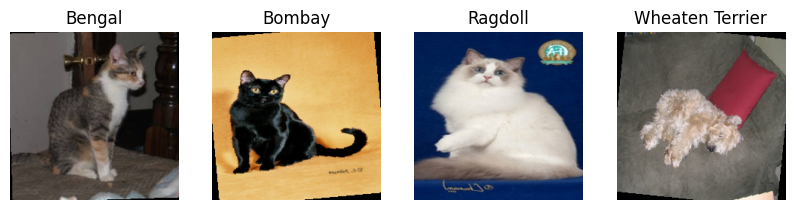

In [8]:
# c - Fournisons un code pour visualiser les 4 prémières d'un batch

images, labels = next(iter(train_loader))

mu = [0.485, 0.456, 0.406] # La moyenne utilisée pour la normalisation de dataset d'origine
sigma = [0.229, 0.224, 0.225] # L'écart type utilisé pour la normalisation de dataset d'origine

def denorm(im, mean, sd):
    im = im.clone()  # faire une copy pour ne pas modifier l'image d’original
    for c, (m, s) in enumerate(zip(mean, sd)):  # Boucle sur chaque canal couleur
        im[c] = im[c] * s + m # enléver la normalisation
    return im # returner l'image sans normalisation

# Visualisation des 4 premières images
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for i in range(4):
    im = denorm(images[i], mu, sigma)   # dénormalisation
    im = im.permute(1, 2, 0).numpy()
    axes[i].imshow(im.clip(0, 1))
    axes[i].set_title(train_dataset.classes[labels[i].item()])
    axes[i].axis("off")
plt.show()

# Question 2 :    
Dans le code d'entraînement, en introduisant toutes les notations nécessaires, donner l'expression mathématique exacte qui est calculée par la ligne
  
```loss = criterion(outputs, labels)```.



En introduisant toutes les notations nécessaires, donnons l'expression mathématique exacte qui est calculée par la ligne
$$
\texttt{loss = criterion(outputs, labels)}.
$$

Soit un batch de taille $b \in \{2,3,4,\dots\}$.  
Chaque image du batch est associée à un label
$$
y_i \in \{1,2,\dots,C\}, \quad \text{avec } C = 37 \text{ classes.}
$$

Le modèle (ici un ResNet-18) renvoie pour la $i$-ème image un vecteur :
$$
\text{outputs}_i = (z_{i1}, z_{i2}, \dots, z_{iC}) \in \mathbb{R}^C.
$$

Ces logits sont convertis en probabilités par la fonction $\textit{softmax}$ :
$$
p_{ij} = \frac{\exp(z_{ij})}{\sum_{k=1}^{C} \exp(z_{ik})},
\quad j=1,\dots,C.
$$

La fonction de perte $\texttt{nn.CrossEntropyLoss}$ en PyTorch applique
le $\textit{softmax}$ suivi de la log-vraisemblance négative.  
Ainsi, la perte pour une donnée $(\text{outputs}_i, y_i)$ est :
$$
\ell(\text{outputs}_i, y_i)
= - \log\!\big(p_{i,y_i}\big)
= - \log \left(
\frac{\exp(z_{i,y_i})}{\sum_{k=1}^{C} \exp(z_{ik})}
\right).
$$

La perte totale renvoyée par la ligne
$\texttt{loss = criterion(outputs, labels)} $
est la moyenne des pertes sur le batch :
$$
\text{loss}
= \frac{1}{b} \sum_{i=1}^{b}
\ell(\text{outputs}_i, y_i)
= -\frac{1}{b} \sum_{i=1}^{b}
\log \left(
\frac{\exp(z_{i,y_i})}{\sum_{k=1}^{C} \exp(z_{ik})}
\right).
$$

# Question 3 :

Dans le code d'entraînement fourni, en quoi consiste la stratégie de data augmentation ?
Refaire le même entraînement sans data augmentation et comparer les résultats obtenus. Par la suite on gardera la version avec data augmentation. On pourra comparer plusieurs courbes de résultats pour illustrer la discussion.

La stratégie de data augmentation consiste à créer de nouvelles images à partir des images existantes en leur appliquant de petites modifications (rotation, recadrage ou changement de couleur). Cela permet d’augmenter le nombre d'image et d’entraîner le modèle avec plus de image différentes, ce qui peut améliorer la robustesse du modèle.

In [9]:
# Définissons les transformation sans data augmantation
train_transforms_2 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load the dataset
train_dataset_2 = datasets.OxfordIIITPet(root='data', split='trainval', transform=train_transforms_2, download=True) # données d'entrainement

# Create data loaders
train_loader_2 = DataLoader(train_dataset_2, batch_size=32, shuffle=True, num_workers=4) # donne 32 images mélanges d'un coup

In [10]:
# On reprend la fonction d'entrainement de dépard en ajoutant un return contenant l'hitorique d'entrainement
# Training function
def train_model_2(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
  hist = {
        "Train_loss": [], "Train_acc": [],
        "Val_loss": [], "Val_acc": []
    }
  for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Accumulate loss and accuracy
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)
        train_accuracy = 100. * correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_accuracy = 100. * correct / total

        hist["Train_loss"].append(train_loss)
        hist["Train_acc"].append(train_accuracy)
        hist["Val_loss"].append(val_loss)
        hist["Val_acc"].append(val_accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')
  return hist

In [11]:
print("Entraînement avec Data Augmentation : ")
# reprendre l'entraînement avec data augmentation pour l'affecter à une variable
model_aug = train_model_2(model, train_loader, val_loader, criterion, optimizer, num_epochs=10)

print("\n Entraînement sans Data Augmentation : ")
# Affectation à une variable du resultat de l'entraînement sans data augmentation
model_sans_aug = train_model_2(model, train_loader_2, val_loader, criterion, optimizer, num_epochs=10)

Entraînement avec Data Augmentation : 
Epoch [1/10], Train Loss: 0.2049, Train Acc: 93.34%, Val Loss: 1.0610, Val Acc: 72.77%
Epoch [2/10], Train Loss: 0.1928, Train Acc: 93.91%, Val Loss: 1.3856, Val Acc: 67.68%
Epoch [3/10], Train Loss: 0.1934, Train Acc: 93.40%, Val Loss: 1.3757, Val Acc: 67.57%
Epoch [4/10], Train Loss: 0.1832, Train Acc: 94.05%, Val Loss: 1.3181, Val Acc: 68.00%
Epoch [5/10], Train Loss: 0.2024, Train Acc: 93.51%, Val Loss: 1.3656, Val Acc: 67.92%
Epoch [6/10], Train Loss: 0.1666, Train Acc: 94.13%, Val Loss: 1.3134, Val Acc: 68.08%
Epoch [7/10], Train Loss: 0.1818, Train Acc: 93.99%, Val Loss: 1.9304, Val Acc: 61.11%
Epoch [8/10], Train Loss: 0.1916, Train Acc: 94.05%, Val Loss: 1.5792, Val Acc: 66.42%
Epoch [9/10], Train Loss: 0.1235, Train Acc: 96.09%, Val Loss: 1.1777, Val Acc: 70.97%
Epoch [10/10], Train Loss: 0.1071, Train Acc: 96.63%, Val Loss: 1.4284, Val Acc: 67.02%

 Entraînement sans Data Augmentation : 
Epoch [1/10], Train Loss: 0.1154, Train Acc: 96.1

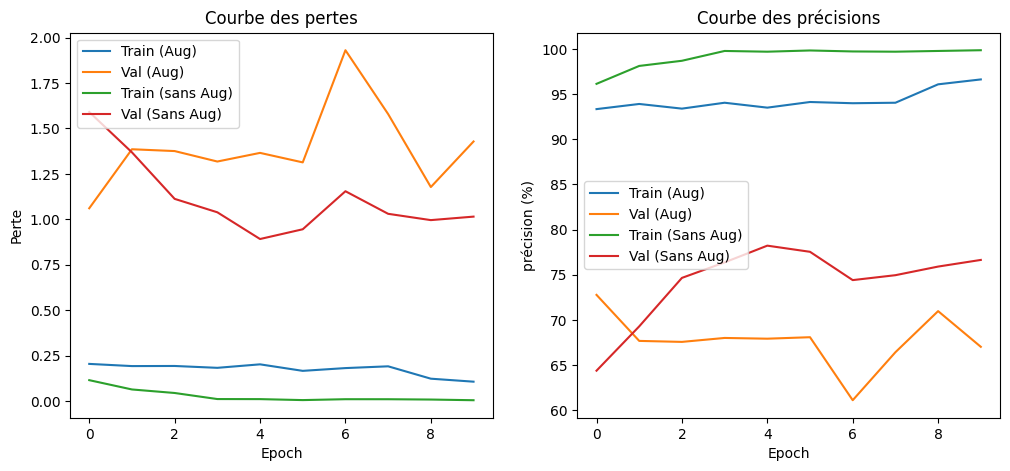

In [12]:
# Comparaison du model avec le data augmentation et sans data augmentation avec des visualisation
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(model_aug["Train_loss"], label="Train (Aug)")
plt.plot(model_aug["Val_loss"], label="Val (Aug)")
plt.plot(model_sans_aug["Train_loss"], label="Train (sans Aug)")
plt.plot(model_sans_aug["Val_loss"], label="Val (Sans Aug)")
plt.xlabel("Epoch")
plt.ylabel("Perte")
plt.title("Courbe des pertes")
plt.legend()

plt.subplot(1,2,2)
plt.plot(model_aug["Train_acc"], label="Train (Aug)")
plt.plot(model_aug["Val_acc"], label="Val (Aug)")
plt.plot(model_sans_aug["Train_acc"], label="Train (Sans Aug)")
plt.plot(model_sans_aug["Val_acc"], label="Val (Sans Aug)")
plt.xlabel("Epoch")
plt.ylabel("précision (%)")
plt.title("Courbe des précisions")
plt.legend()

plt.show()

D’après les courbes, on voit que sans data augmentation le modèle apprend vite et atteint presque 100% de précision sur l’entraînement, mais la précision de validation chute après quelques époques et la perte augmente, ce qui montre le sur-apprentissage. Avec le data augmentation, la précision d’entraînement est un peu plus bas, mais la précision de validation est stable. Cela veut dire que le modèle est plus robuste et généralise mieux. Même si les résultats d’entraînement sont moins bon, la version avec augmentation est fiable pour de nouvelles images.

# Question 4 :

On se propose de comparer les performances de ResNet18 avec un CNN plus simple :

3.a) Définir un model CNN constitué de 3 couches de (convolutions + Maxpooling 2x2) suivies de 3 couches linéaires. Il est demander de préciser la taille des tensor après chaque opération de la fonction forward.

3.b) Entraîner ce modèle comme plus haut. Comparer les résultats obtenus.


In [13]:
#3.a - Définissons un model CNN constitué de 3 couches de (convolutions + Maxpooling 2x2) suivies de 3 couches linéaires

import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, num_classes=37):
        super(CNN, self).__init__()
        # 3 blocs convolution + maxpool
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)   # (3 → 32 filtres)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # (32 → 64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # (64 → 128)
        self.pool = nn.MaxPool2d(2, 2)

        # couches linéaires
        self.fc1 = nn.Linear(128 * 28 * 28, 512)  # calcul après 3 poolings
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x): # Entrée : (32, 3, 224, 224)
        x = self.pool(F.relu(self.conv1(x)))  # (32, 32, 112, 112)
        x = self.pool(F.relu(self.conv2(x)))  #  (32, 64, 56, 56)
        x = self.pool(F.relu(self.conv3(x))) #  (32, 128, 28, 28)
        x = x.view(x.size(0), -1)  #  (32, 128*28*28 = 100352)

        x = F.relu(self.fc1(x))  #  (32, 512)
        x = F.relu(self.fc2(x))  #  (32, 256)
        x = self.fc3(x)          #  (32, 37)

        return x

In [14]:
# 3.b - Entraînons ce modèle comme plus haut.
# Créer le modèle CNN
simple_cnn = CNN(num_classes=37).to(device)

# Définission optimiseur
optimizer_cnn = optim.Adam(simple_cnn.parameters(), lr=0.001)

# Entraînement (même fonction que pour ResNet18)
model_cnn = train_model_2(simple_cnn, train_loader, val_loader, criterion, optimizer_cnn, num_epochs=10)


Epoch [1/10], Train Loss: 3.5640, Train Acc: 4.76%, Val Loss: 3.4712, Val Acc: 6.46%
Epoch [2/10], Train Loss: 3.3995, Train Acc: 6.55%, Val Loss: 3.4173, Val Acc: 6.68%
Epoch [3/10], Train Loss: 3.2935, Train Acc: 9.27%, Val Loss: 3.3350, Val Acc: 9.43%
Epoch [4/10], Train Loss: 3.1808, Train Acc: 11.03%, Val Loss: 3.2645, Val Acc: 9.70%
Epoch [5/10], Train Loss: 3.0778, Train Acc: 13.48%, Val Loss: 3.2504, Val Acc: 10.55%
Epoch [6/10], Train Loss: 2.9452, Train Acc: 16.22%, Val Loss: 3.1826, Val Acc: 12.13%
Epoch [7/10], Train Loss: 2.7764, Train Acc: 20.65%, Val Loss: 3.1446, Val Acc: 14.72%
Epoch [8/10], Train Loss: 2.5971, Train Acc: 25.68%, Val Loss: 3.1057, Val Acc: 15.04%
Epoch [9/10], Train Loss: 2.3896, Train Acc: 30.30%, Val Loss: 3.2248, Val Acc: 16.14%
Epoch [10/10], Train Loss: 2.0988, Train Acc: 39.84%, Val Loss: 3.3692, Val Acc: 16.41%


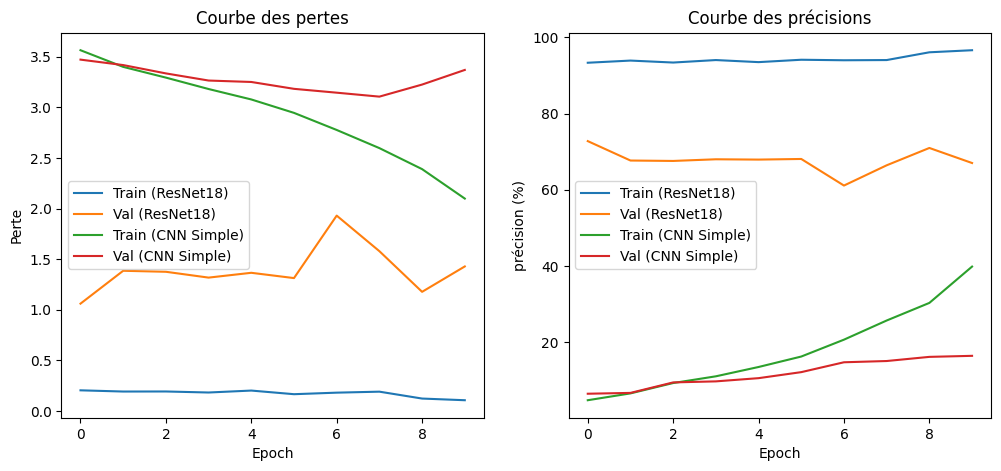

In [15]:
# Comparons les résultats obtenus
# Comparaison du model ResNet18 avec le data augmentation et CNN plus simple avec des visualisation
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(model_aug["Train_loss"], label="Train (ResNet18)")
plt.plot(model_aug["Val_loss"], label="Val (ResNet18)")
plt.plot(model_cnn["Train_loss"], label="Train (CNN Simple)")
plt.plot(model_cnn["Val_loss"], label="Val (CNN Simple)")
plt.xlabel("Epoch")
plt.ylabel("Perte")
plt.title("Courbe des pertes")
plt.legend()

plt.subplot(1,2,2)
plt.plot(model_aug["Train_acc"], label="Train (ResNet18)")
plt.plot(model_aug["Val_acc"], label="Val (ResNet18)")
plt.plot(model_cnn["Train_acc"], label="Train (CNN Simple)")
plt.plot(model_cnn["Val_acc"], label="Val (CNN Simple)")
plt.xlabel("Epoch")
plt.ylabel("précision (%)")
plt.title("Courbe des précisions")
plt.legend()

plt.show()

D’après les courbes, on voit que ResNet18 donne de meilleurs résultats que le CNN simple. La perte dans l'entraînement et la validation est plus basse et la précision atteint presque 100% d'entraînement et plus de 70% en validation. Par contre, le CNN simple garde une précision faible, autour de 20% en validation, et il n’arrive pas à apprendre correctement. Cela montre que le fintuning est plus adapté et plus efficace que d’entraîner un petit CNN depuis zéro sur ce type de base de données.

# Question 5 :

Pourquoi dit-on que le code fourni effectue un finetuning ?
Proposer une expérience qui permettre de discuter l'intérêt du finetuning. On commencera par justifier la démarche avant de proposer du code.

On dit que le code fourni effectue un finetuning parce qu’il prend un modèle ResNet18 déjà appris sur ImageNet (pré-entraîné sur ImageNet) et il change juste la dernière couche pour avoir 37 classes en sortie comme notre base Oxford-IIIT Pet.

L’avantage c’est que le modèle connaît déjà des trucs (bords, formes, textures) grâce au grand dataset ImageNet. Du coup il apprend plus vite sur notre petit dataset et fait moins d’erreurs. Si on partait de zéro, il faudrait probablement beaucoup plus d’images pour arriver au même niveau.

### Justification de démarche :
Pour discuter l’intérêt du finetuning, on peut faire une expérience où l’on entraîne un modèle ResNet18 depuis zéro avec notre base de données et, en parallèle, un autre ResNet18 en finetuning comme vu plus haut. Ensuite, on compare leurs résultats (précision, perte, etc.) afin de voir lequel apprend mieux et généralise le plus.

In [16]:
# Entrainement de resnet18 à partir de zéro
# Define the model
model_zero = models.resnet18(weights = None) # resnet sans pré-entraînement

# Modify the last layer
model_zero.fc = nn.Linear(model_zero.fc.in_features, 37) # Remplacer la dernière couche

# Move the model to the device
model_zero = model_zero.to(device)

# Define optimizer
optimizer_zero = optim.Adam(model_zero.parameters(), lr=0.001)

model_z = train_model_2(model_zero, train_loader, val_loader, criterion, optimizer_zero, num_epochs=10) # entrainement du model

Epoch [1/10], Train Loss: 3.6109, Train Acc: 5.79%, Val Loss: 3.6781, Val Acc: 5.75%
Epoch [2/10], Train Loss: 3.2839, Train Acc: 11.11%, Val Loss: 3.8708, Val Acc: 6.24%
Epoch [3/10], Train Loss: 3.1297, Train Acc: 13.72%, Val Loss: 3.3287, Val Acc: 12.65%
Epoch [4/10], Train Loss: 2.9789, Train Acc: 16.79%, Val Loss: 3.3458, Val Acc: 11.45%
Epoch [5/10], Train Loss: 2.8799, Train Acc: 19.51%, Val Loss: 3.0666, Val Acc: 14.96%
Epoch [6/10], Train Loss: 2.7463, Train Acc: 21.55%, Val Loss: 2.8788, Val Acc: 19.43%
Epoch [7/10], Train Loss: 2.6134, Train Acc: 26.14%, Val Loss: 2.9868, Val Acc: 18.32%
Epoch [8/10], Train Loss: 2.5149, Train Acc: 28.26%, Val Loss: 3.0338, Val Acc: 19.32%
Epoch [9/10], Train Loss: 2.3720, Train Acc: 30.57%, Val Loss: 2.8094, Val Acc: 22.19%
Epoch [10/10], Train Loss: 2.2620, Train Acc: 33.56%, Val Loss: 3.1108, Val Acc: 20.88%


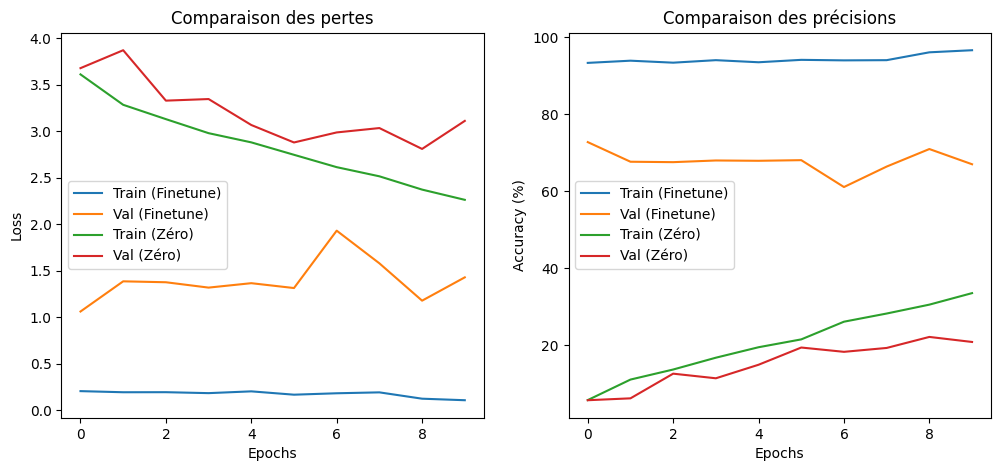

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(model_aug["Train_loss"], label="Train (Finetune)")
plt.plot(model_aug["Val_loss"], label="Val (Finetune)")
plt.plot(model_z["Train_loss"], label="Train (Zéro)")
plt.plot(model_z["Val_loss"], label="Val (Zéro)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Comparaison des pertes")
plt.legend()

plt.subplot(1,2,2)
plt.plot(model_aug["Train_acc"], label="Train (Finetune)")
plt.plot(model_aug["Val_acc"], label="Val (Finetune)")
plt.plot(model_z["Train_acc"], label="Train (Zéro)")
plt.plot(model_z["Val_acc"], label="Val (Zéro)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Comparaison des précisions")
plt.legend()

plt.show()

On voit que le modèle avec finetuning (ResNet18 pré-entraîné) est plus performant que celui entraîné depuis zéro. Sa perte descend rapidement et reste plus basse, et sa précision atteint presque 100% dans l'entraînement et plus de 70% en validation. Alors que, le modèle entraîné à zéro progresse doucement, sa perte reste haute et sa précision ne dépasse pas environ 40% d'entraînement et 20% en validation. Cela montre que le finetuning apporte beaucoup d'avantage car le modèle profite déjà de ce qu’il a appris sur ImageNet.

# Question 6 :     
Proposer une stratégie d'entraînement qui puisse fournir de meilleurs résultats que le code fourni par l'énoncé.
Vérifier expérimentalement si cette stratégie est bien meilleure.

Une stratégie meilleure que le code de base est de commencer par geler toutes les couches du ResNet18 qui vient d’ImageNet, et changer seulement la dernière couche pour les 37 classes. Comme ça, on garde tous ce qui est déjà appris et on évite de trop apprendre sur notre petit ensemble d'image. Après, on peut dégeler un peu les dernières couches (finetuning partiel). On peut aussi ajouter de data augmentation (flips, rotations, bruit) pour rendre le modèle plus solide. Pour tester si c’est mieux, on compare deux entraînements : le premier avec juste la dernière couche, et le deuxième avec finetuning partiel et augmentation. Normalement, le deuxième va mieux marcher sur la validation car il apprend un peu plus sans trop sur-apprendre.

In [18]:
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # choisir le GPU si disponible

# Define transformations for the training set (ajout ColorJitter)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),   # redimentionnement à 224x224
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),  # data augmentation
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # data augmentation en plus
    transforms.ToTensor(),  # passage en tenseur
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Normalisation
])


# Load the dataset
train_dataset = datasets.OxfordIIITPet(root='data', split='trainval', transform=train_transforms, download=True) # données d'entrainement

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4) # donne 32 images mélangées d'un coup

# Define the model
model = models.resnet18(weights='DEFAULT') # resnet (réseau de neurones déjà entrainé sur ImageNet)

# Modify the last layer
model.fc = nn.Linear(model.fc.in_features, 37) # Remplacer la dernière couche

# Move the model to the device
model = model.to(device)

In [19]:
# géle tous
for param in model.parameters():
    param.requires_grad = False

for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

# Train the model
model_gel = train_model_2(model, train_loader, val_loader, criterion, optimizer, num_epochs=10)

Epoch [1/10], Train Loss: 1.7941, Train Acc: 61.58%, Val Loss: 0.8334, Val Acc: 84.06%
Epoch [2/10], Train Loss: 0.6003, Train Acc: 87.91%, Val Loss: 0.5641, Val Acc: 84.87%
Epoch [3/10], Train Loss: 0.3550, Train Acc: 92.26%, Val Loss: 0.4954, Val Acc: 86.35%
Epoch [4/10], Train Loss: 0.2140, Train Acc: 96.01%, Val Loss: 0.4497, Val Acc: 87.38%
Epoch [5/10], Train Loss: 0.1370, Train Acc: 97.80%, Val Loss: 0.4866, Val Acc: 85.80%
Epoch [6/10], Train Loss: 0.0998, Train Acc: 98.37%, Val Loss: 0.4531, Val Acc: 86.86%
Epoch [7/10], Train Loss: 0.0738, Train Acc: 98.99%, Val Loss: 0.4484, Val Acc: 86.94%
Epoch [8/10], Train Loss: 0.0533, Train Acc: 99.57%, Val Loss: 0.4313, Val Acc: 87.76%
Epoch [9/10], Train Loss: 0.0414, Train Acc: 99.65%, Val Loss: 0.4584, Val Acc: 86.84%
Epoch [10/10], Train Loss: 0.0384, Train Acc: 99.59%, Val Loss: 0.4557, Val Acc: 87.03%


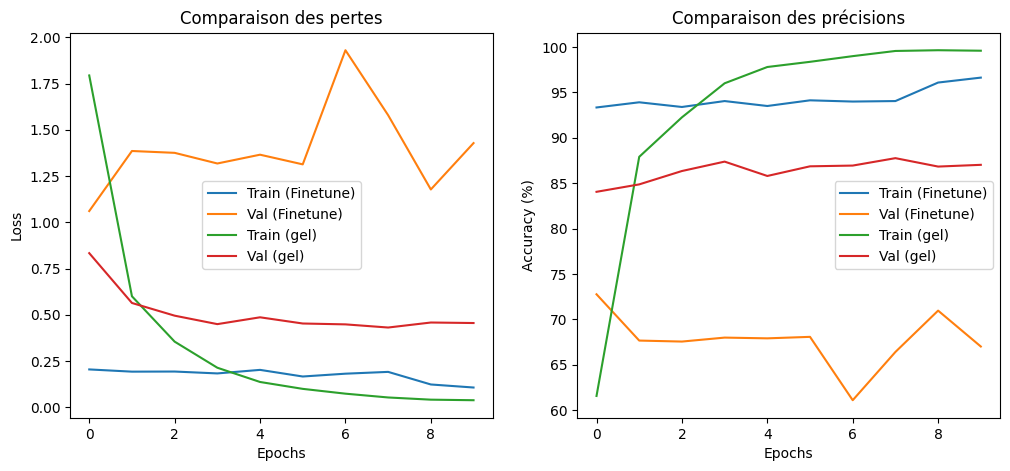

In [20]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(model_aug["Train_loss"], label="Train (Finetune)")
plt.plot(model_aug["Val_loss"], label="Val (Finetune)")
plt.plot(model_gel["Train_loss"], label="Train (gel)")
plt.plot(model_gel["Val_loss"], label="Val (gel)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Comparaison des pertes")
plt.legend()

plt.subplot(1,2,2)
plt.plot(model_aug["Train_acc"], label="Train (Finetune)")
plt.plot(model_aug["Val_acc"], label="Val (Finetune)")
plt.plot(model_gel["Train_acc"], label="Train (gel)")
plt.plot(model_gel["Val_acc"], label="Val (gel)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Comparaison des précisions")
plt.legend()

plt.show()